In [156]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns


In [157]:
df = pd.read_csv("paper_leak.csv")

In [158]:
df.head()

,Date of Exam/Incident,Exam Name,Conducting Body,Conducting Body Type,Area(s) of Incident,Leak Confirmation Status
0,26-08-2024,B.Ed. 4th Sem Exam : Creating an Inclusive School,Tamil Nadu Teachers Education University,State,Tamilnadu,accused
1,04-08-2024,MBA 1st year Exam,Pondicherry University,Central,Pondicherry,confirmed
2,06-07-2024,Foreign Medical Graduate Examination,National Board of Examinations in Medical Scie...,Central,Kerala,accused
3,30-06-2024,Agriculture Development Officers�,Punjab Public Service Comission,State,Punjab,accused
4,18-06-2024,UGC NET 2024,National Testing Agency,Central,All India,accused


In [159]:
df.shape

(66, 6)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Date of Exam/Incident     66 non-null     object
 1   Exam Name                 66 non-null     object
 2   Conducting Body           66 non-null     object
 3   Conducting Body Type      66 non-null     object
 4   Area(s) of Incident       66 non-null     object
 5   Leak Confirmation Status  66 non-null     object
dtypes: object(6)
memory usage: 3.2+ KB


In [161]:
df['Date of Exam/Incident'] = pd.to_datetime(df['Date of Exam/Incident'])
df['Year'] = df['Date of Exam/Incident'].dt.year
df['Month'] = df['Date of Exam/Incident'].dt.month
df['Day'] = df['Date of Exam/Incident'].dt.day
df = df.drop('Date of Exam/Incident', axis=1)



/tmp/ipykernel_796/2703813650.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date of Exam/Incident'] = pd.to_datetime(df['Date of Exam/Incident'])


In [162]:
df['Leak Confirmation Status'] = df['Leak Confirmation Status'].map({'accused':0,'confirmed':1})

In [163]:
df['Conducting Body Type'].unique()

array(['State', 'Central', 'Private'], dtype=object)

In [164]:
df

,Exam Name,Conducting Body,Conducting Body Type,Area(s) of Incident,Leak Confirmation Status,Year,Month,Day
0,B.Ed. 4th Sem Exam : Creating an Inclusive School,Tamil Nadu Teachers Education University,State,Tamilnadu,0,2024,8,26
1,MBA 1st year Exam,Pondicherry University,Central,Pondicherry,1,2024,8,4
2,Foreign Medical Graduate Examination,National Board of Examinations in Medical Scie...,Central,Kerala,0,2024,7,6
3,Agriculture Development Officers�,Punjab Public Service Comission,State,Punjab,0,2024,6,30
4,UGC NET 2024,National Testing Agency,Central,All India,0,2024,6,18
...,...,...,...,...,...,...,...,...
61,NEET Phase 1 2016,CBSE,Central,Uttar Pradesh,1,2016,5,1
62,UP CPMT 2015,"King George's Medical University�, Lucknow",State,Uttar Pradesh,1,2015,5,25
63,AIPMT 2015,CBSE,Central,All India,1,2015,5,3
64,Provincial civil services preliminary examination,Uttar Pradesh Public Service Comission,State,Uttar Pradesh,1,2015,3,30


In [165]:
df['Leak Confirmation Status'].value_counts()

,count
Leak Confirmation Status,
1,48
0,18


<Axes: xlabel='Leak Confirmation Status', ylabel='count'>

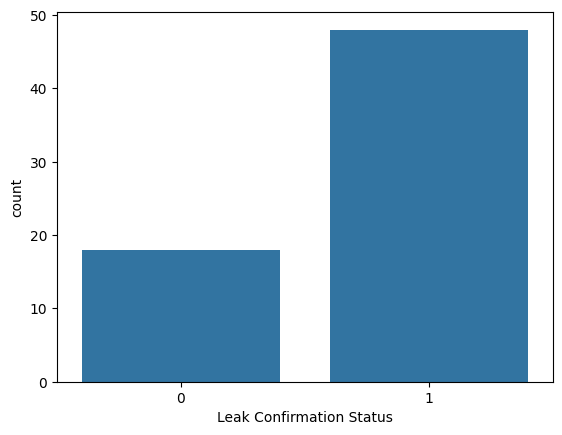

In [166]:
sns.countplot(x='Leak Confirmation Status',data=df)

In [167]:
cols = ['Area(s) of Incident','Conducting Body Type']
X = df[cols]
y = df['Leak Confirmation Status']

In [168]:
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), ['Area(s) of Incident', 'Conducting Body Type'])
])

In [169]:
#here you add ,stratify=y because it removes the minor imbalance in test data.
#the test data is imbalnced because of small dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
model = LogisticRegression()

In [171]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight="balanced"))
])

In [172]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area(s) of Incident',
                                                   'Conducting Body Type'])])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [173]:
y_pred = pipeline.predict(X_test)

In [174]:
acc_score = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc_score)

Accuracy Score: 0.7142857142857143


In [175]:
y_pred2 = pipeline.predict(X_train)
acc_score2 = accuracy_score(y_train, y_pred2)
print("Accuracy Score:", acc_score2)

Accuracy Score: 0.8461538461538461


In [176]:
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.82      0.82      0.82        11

    accuracy                           0.71        14
   macro avg       0.58      0.58      0.58        14
weighted avg       0.71      0.71      0.71        14



In [177]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[1 2]
 [2 9]]
